In [32]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import math
import scipy.stats as stats

In [33]:
np.random.seed(42)
random.seed(42)
plt.style.use('ggplot')

$$ y_1^2+\cdots+y_n^2 \sim \chi^2_n \:if\:y\sim iid\:N(0,1) $$
$$If \: x_1,\cdots,x_n \sim iid\:N(\mu,\sigma^2)$$
$$ \frac{(n-1)\widehat{s}^2}{\sigma^2}\sim  \:\chi^2_{n-1}$$

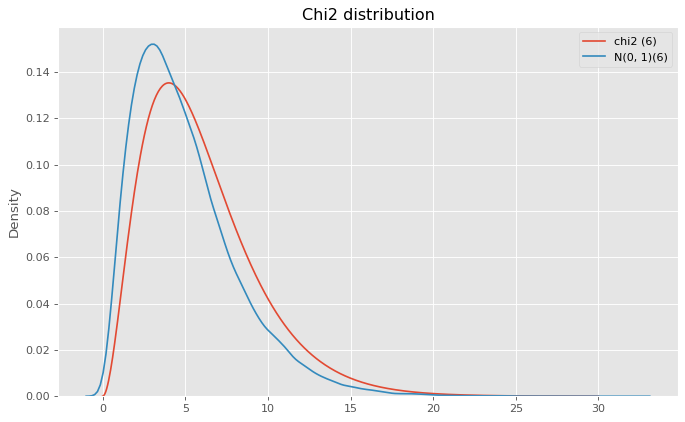

In [34]:
x = np.linspace(0, 30, 500)
y = stats.chi2.pdf(x, df=6)
true_var = 1

values = []
for i in range(70000):
    n = 6
    sample = np.random.normal(0, np.sqrt(true_var), n)

    s = np.var(sample, ddof=1)
    value = (n - 1) * s / true_var
    values.append(value)

values = np.array(values)
fig, ax = plt.subplots(figsize = (10, 6), dpi=80)
ax.plot(x, y, label="chi2 (6)")
plt.title("Chi2 distribution")
sns.kdeplot(values, label=f"N(0, {true_var})(6)")
plt.legend()
plt.show()


We can use t-statistic when the number of observations is small and constraint on distribution above holds. To test hypothesis we need to use Student's distribtuion  (t-distribution)
$$ t=\frac{\overline{x}-\mu_0}{\sqrt{\widehat{s}^2/n}} \sim t(n-1) $$


t-distribution with n degrees of freedom can be written as:
$$ t(n)\sim N(0,1)\cdot\frac{1}{\sqrt{\chi^2_n/n}} $$

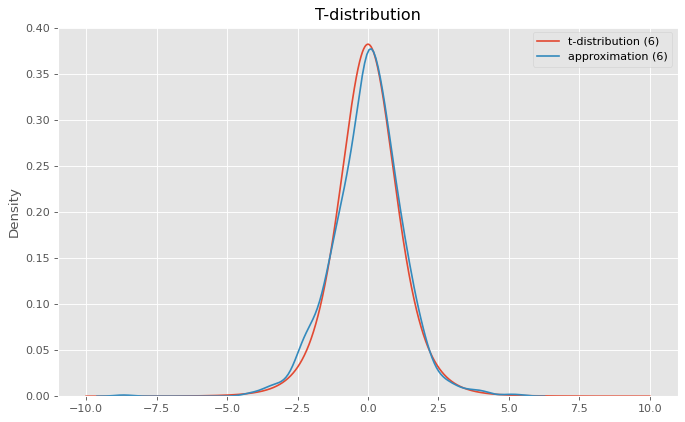

In [35]:
n = 6
x = np.linspace(-10, 10, 2000)
y = stats.t.pdf(x, df=n)
true_var = 1

size = 1000
p = stats.norm.rvs(loc=0, scale=1, size=size)
q = stats.chi2.rvs(df=n, size=size)
t_samples = p / np.sqrt(q / n)

fig, ax = plt.subplots(figsize = (10, 6), dpi=80)
ax.plot(x, y, label=f"t-distribution ({n})")
plt.title("T-distribution")
sns.kdeplot(t_samples, label=f"approximation ({n})")
plt.legend()
plt.show()


Fischer's theorem:
$$ \chi^2_n+\chi^2_m\sim \chi^2_{n+m} $$

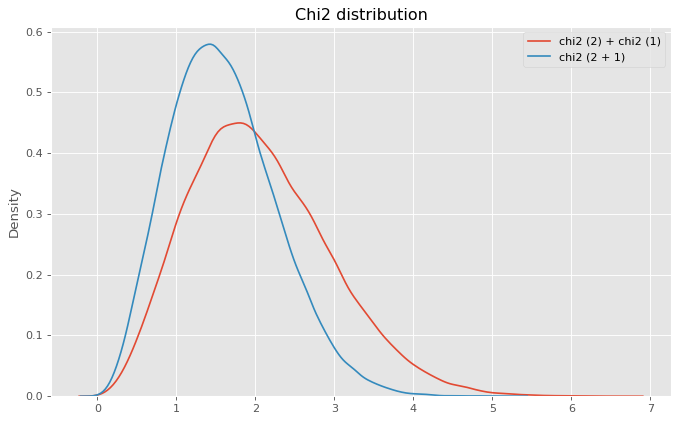

In [36]:
a = random.randint(2, 6)
b = random.randint(1, 7)

size=50000
y = stats.chi.rvs(size=size, df=a+b)
fig, ax = plt.subplots(figsize = (10, 6), dpi=80)

#Distributions with df = a, b
y_a = stats.chi.rvs(size=size, df=a)
y_b = stats.chi.rvs(size=size, df=b)
sns.kdeplot(y_a + y_b, label=f"chi2 ({a}) + chi2 ({b})", ax=ax)

sns.kdeplot(y, label=f"chi2 ({a} + {b})", ax=ax)
plt.title("Chi2 distribution")

plt.legend()
plt.show()


To test hypothesis with these distributions we have many different criterias, for example: 
$$
H_0:\mu=\mu_0,\: H_a:\mu \ne \mu_0
$$
$$
t=\frac{\overline{x}-\mu_0}{\sqrt{s^2/n}} \sim t(n-1)
$$
for mean
$$
H_0:\sigma=\sigma_0,\: H_a:\sigma \ne \sigma_0
$$
$$
\sum_{i=1}^n\frac{(x_i-\mu)^2}{\sigma_0^2}\sim \chi^2_n
$$
for variance

In [37]:
""" try it yourself ▬▬ι═══════ﺤ """

' try it yourself ▬▬ι═══════ﺤ '

Criteria for difference of proportions is more interesting part.

$$
x_1^t,\cdots x_n^t \sim iid \:N(\mu_t,\sigma^2_t)
$$
$$
x_1^c,\cdots,x_n^c \sim iid \: N(\mu_c, \sigma^2_c)
$$
$$
t=\frac{\overline{x}_t-\overline{x}_c-(\mu_t-\mu_c)}{\sqrt{\frac{\sigma^2_t}{n_t} +\frac{\sigma^2_c}{n_c} }}
$$
a) If H0 states that variances are equal then:
$$ t\sim t(n_t+n_c-2) $$
b) otherwise:
$$ t \sim^{approx}t(v) $$
$$ v=\frac{ (\frac{s_t^2}{n_t} + \frac{s_c^2}{n_c})^2 }{
\frac{s_t^4}{n_t^2(n_t-1)}+\frac{s_c^4}{n_c^2(n_c-1)}
} $$

In [ ]:
#H_0: p_c = p_t
#Welch's test
n_t, n_c = 15, 17
x_t = np.random.normal(loc=4, scale=2.1, size=n_t)
x_c = np.random.normal(loc=4.2, scale=2.05, size=n_c)

def approx_v(s_t, s_c, n_t, n_c) -> int:
    p = s_t ** 2 / n_t + s_c ** 2 / n_c
    q = s_t ** 4 / (n_t ** 2 * (n_t - 1)) + s_c ** 4 / (n_c ** 2 * (n_c - 1))
    #Floor so alpha will less likely exceed the threshold
    return math.floor(p ** 2 / q)

def calc_t(mde, p_t, p_c, s_t, s_c, n_t, n_c):
    return (p_t - p_c - mde) / (np.sqrt(s_t ** 2 / n_t + s_c ** 2 / n_c))

s_t = np.sqrt( np.var(x_t, ddof=1) )
s_c = np.sqrt( np.var(x_c, ddof=1) )
p_t = x_t.mean()
p_c = x_c.mean()
v = approx_v(s_t, s_c, n_t, n_c)
alpha = 0.05

print("v:", v)
print("t-value:", calc_t(0.2, p_t, p_c, s_t, s_c, n_t, n_c))
print(stats.t.ppf(q=1-alpha, df=v))


v: 26
t-value: 0.01227835050533766
1.7056179197592727


In [39]:
#Alpha should be around 0.05
alpha = 0.05
n = 1000

count = 0
for i in range(n):
    n_t, n_c = 15, 17
    x_t = np.random.normal(loc=4, scale=2.1, size=n_t)
    x_c = np.random.normal(loc=4.2, scale=2.05, size=n_c)
    s_t = np.sqrt( np.var(x_t, ddof=1) )
    s_c = np.sqrt( np.var(x_c, ddof=1) )
    p_t = x_t.mean()
    p_c = x_c.mean()
    v = approx_v(s_t, s_c, n_t, n_c)

    t_val = calc_t(0.2, p_t, p_c, s_t, s_c, n_t, n_c)
    t_crit = stats.t.ppf(q=1-alpha, df=v)
    count += 1 if t_val > t_crit else 0
print(count/n)


0.015


In [40]:
n_t, n_c = 16, 19
x_t = np.random.normal(loc=4, scale=2.1, size=n_t)
x_c = np.random.normal(loc=4.2, scale=2.05, size=n_c)

result = stats.ttest_ind(x_t, x_c, equal_var=False, alternative='greater')
print(f"scipy: df = {result.df:.4f}, t = {result.statistic:.4f}")

s_t, p_t = np.sqrt( np.var(x_t, ddof=1) ), x_t.mean()
s_c, p_c = np.sqrt( np.var(x_c, ddof=1) ), x_c.mean()
v = approx_v(s_t, s_c, n_t, n_c)

t_val = calc_t(0.2, p_t, p_c, s_t, s_c, n_t, n_c)
print(f"hand: df = {v}, t = {t_val}")

scipy: df = 28.8906, t = 1.1165
hand: df = 28, t = 0.7729814328487226
